# Mixed distributions in QMCPy

### What this notebook demonstrates

- `Mixture` correctly generates samples from a mixture distribution using one additional selector coordinate.
- The selector creates a discontinuity at component boundaries, which may reduce QMC integration performance.
- Because expectation is linear, a mixture expectation can alternatively be evaluated componentwise.
- Direct mixture samples remain useful for nonlinear distribution summaries such as medians and quantiles.
- Direct `Mixture` integration through the current `AbstractIntegrand` pipeline remains unsupported because the sampler dimension is $d+1$ while the output dimension is $d$.

## 1. Mixture distribution

For component distributions $P_j$ and positive probabilities $p_j$ that sum to one,
$$
P_{\mathrm{mix}}=\sum_j p_jP_j,
\qquad p_j>0,
\qquad \sum_jp_j=1.
$$
When all components have densities with respect to a common reference measure,
$$
\rho_{\mathrm{mix}}(x)=\sum_jp_j\rho_j(x).
$$

**Sampling from a mixture** means generating observations distributed according to $P_{\mathrm{mix}}$. **Integrating an expectation under a mixture** means evaluating $E_{\mathrm{mix}}[f(X)]$. `Mixture` directly implements the first task; the second can use those samples or, by linearity of expectation, separate componentwise estimates.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/mixed_distributions.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  !pip install -q qmcpy


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.integrate import quad
from scipy.stats import lognorm

from qmcpy import DigitalNetB2, Gaussian, Mixture, SciPyWrapper, Uniform

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#3366CC", "#E67300", "#2E8B57"]

## 2. Selector sampling and boundary convention

For a two-component, one-dimensional mixture with probabilities $0.3$ and $0.7$, the transform is

```text
(u_0, u_1)
   |
   +-- 0 <= u_0 < 0.3 --> component 0 --> T_0(u_1)
   |
   +-- 0.3 <= u_0 <= 1 --> component 1 --> T_1(u_1)
```

Thus
$$
\text{sampler dimension}=2,
\qquad
\text{output dimension}=1.
$$
In general, `Mixture` consumes one selector coordinate and maps
$$
[0,1]^{d+1}\longrightarrow\mathbb{R}^d.
$$
The remaining $d$ coordinates pass through the selected component's complete transform. The following example uses one-dimensional Gaussians centered at $-2$ and $2.5$.

In [3]:
intro_components = [
    Gaussian(DigitalNetB2(1, seed=11), mean=-2.0, covariance=0.35),
    Gaussian(DigitalNetB2(1, seed=13), mean=2.5, covariance=0.55),
]
intro_probabilities = np.array([0.3, 0.7])
intro = Mixture(DigitalNetB2(2, seed=7), intro_components, intro_probabilities)
intro_x = intro(2048)

assert intro_x.shape == (2048, 1)
print("outer sampler dimension:", intro.discrete_distrib.d)
print("output dimension:       ", intro.d)
print("mixture sample shape:   ", intro_x.shape)

outer sampler dimension: 2
output dimension:        1
mixture sample shape:    (2048, 1)


The 2,048 outer points each have two coordinates, but the returned observations each have one coordinate. The selector $u_0$ is consumed by `Mixture`; only the transformed value from $u_1$ appears in the output. Component 0 owns $[0,0.3)$ and component 1 owns $[0.3,1]$.

Only the deterministic probe below calls the internal `_transform` method to test exact boundary values. Ordinary sampling uses the public interface.

In [4]:
boundary_u = np.array([
    [0.0, 0.5],
    [np.nextafter(0.3, 0.0), 0.5],
    [0.3, 0.5],
    [np.nextafter(0.3, 1.0), 0.5],
    [1.0, 0.5],
])
boundary_x = intro._transform(boundary_u)[:, 0]
boundary_component = np.searchsorted(
    np.cumsum(intro_probabilities), boundary_u[:, 0], side="right"
)
boundary_component = np.minimum(boundary_component, 1)

boundary_labels = [
    "0", "nextafter(0.3, 0)", "0.3", "nextafter(0.3, 1)", "1"
]
for label, component, value in zip(
    boundary_labels, boundary_component, boundary_x
):
    print(f"u0={label} -> component {component} -> x={value:.1f}")

np.testing.assert_array_equal(boundary_component, [0, 0, 1, 1, 1])
np.testing.assert_allclose(boundary_x, [-2.0, -2.0, 2.5, 2.5, 2.5])

u0=0 -> component 0 -> x=-2.0
u0=nextafter(0.3, 0) -> component 0 -> x=-2.0
u0=0.3 -> component 1 -> x=2.5
u0=nextafter(0.3, 1) -> component 1 -> x=2.5
u0=1 -> component 1 -> x=2.5


| $u_0$ | Selected component | Transformed value |
| --- | ---: | ---: |
| $0$ | 0 | $-2.0$ |
| Just below $0.3$ | 0 | $-2.0$ |
| $0.3$ | 1 | $2.5$ |
| Just above $0.3$ | 1 | $2.5$ |
| $1$ | 1 | $2.5$ |

The exact cumulative boundary $u_0=0.3$ belongs to component 1 under the left-closed, right-open convention; $u_0=1$ is assigned to the final component. With $u_1=0.5$, each Gaussian transform returns its median, equal to its mean here, so the boundary behavior is unambiguous.

## 3. What happens to QMC at the selector boundary?

Consider
$$
P_{\mathrm{mix}}=0.3\,U(0,1)+0.7\,U(2,3),
\qquad f(x)=x^2.
$$
Its exact expectation is
$$
E[X^2]=0.3\left(\frac13\right)+0.7\left(\frac{19}{3}\right)=\frac{68}{15}.
$$
At fixed $u_1=0.5$, the selector transform is
$$
T(u_0,0.5)=
\begin{cases}
0.5, & 0\le u_0<0.3,\\
2.5, & 0.3\le u_0\le1.
\end{cases}
$$
The individual component transforms are smooth here; the discontinuity is introduced by the component selector.

### Selector QMC versus componentwise QMC

Linearity gives
$$
E_{\mathrm{mix}}[f(X)]=\sum_jp_jE_j[f(X)].
$$

```text
Selector approach:

2D QMC -> selector u_0 -> T_j(u_1) -> f(x)

Componentwise approach:

1D QMC -> T_0(u) -> f(x) -> I_0
1D QMC -> T_1(u) -> f(x) -> I_1
                                |
                         0.3 I_0 + 0.7 I_1
```

| Method | Points | Total component transforms |
| --- | --- | ---: |
| Selector | $N$ selector points | $N$ |
| Componentwise, equal budget | $N/2$ per component | $N$ |
| Componentwise, full | $N$ per component | $2N$ |

The equal-budget $N/2$-per-component allocation only matches the number of component transforms; it is not claimed to be optimal across mixture components.

All three curves below use `DigitalNetB2`. The horizontal value $N$ is the selector sample count and equal-budget transform count; the full componentwise curve deliberately uses twice as many component transforms.

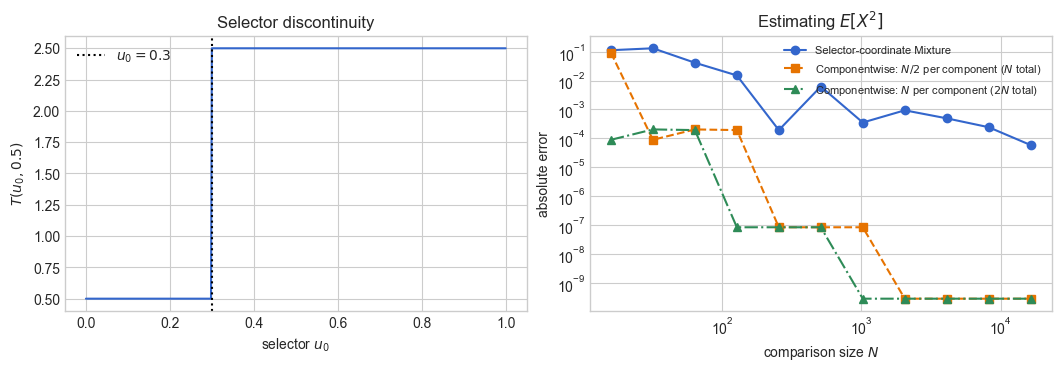

Exact expectation:                            4.533333333333
Selector error (N total):                     5.850e-05
Equal-budget componentwise error (N/2 each): 2.794e-10
N-per-component error (2N total):            2.794e-10


In [5]:
comparison_sizes = 2 ** np.arange(4, 15)
comparison_probabilities = np.array([0.3, 0.7])
comparison_components = [
    Uniform(DigitalNetB2(1, seed=103), lower_bound=0.0, upper_bound=1.0),
    Uniform(DigitalNetB2(1, seed=107), lower_bound=2.0, upper_bound=3.0),
]
selector_mixture = Mixture(
    DigitalNetB2(2, seed=101),
    comparison_components,
    comparison_probabilities,
)
comparison_n_max = int(comparison_sizes[-1])
selector_values = selector_mixture(comparison_n_max)[:, 0]
component_values = [
    component(comparison_n_max)[:, 0] for component in comparison_components
]
exact_second_moment = 68.0 / 15.0
selector_estimates = np.array([
    np.mean(selector_values[:n] ** 2) for n in comparison_sizes
])
equal_budget_componentwise_estimates = np.array([
    sum(
        probability * np.mean(values[:n // 2] ** 2)
        for probability, values in zip(
            comparison_probabilities, component_values
        )
    )
    for n in comparison_sizes
])
n_per_component_estimates = np.array([
    sum(
        probability * np.mean(values[:n] ** 2)
        for probability, values in zip(
            comparison_probabilities, component_values
        )
    )
    for n in comparison_sizes
])
selector_errors = np.abs(selector_estimates - exact_second_moment)
equal_budget_componentwise_errors = np.abs(
    equal_budget_componentwise_estimates - exact_second_moment
)
n_per_component_errors = np.abs(
    n_per_component_estimates - exact_second_moment
)
assert np.all(np.isfinite(selector_errors))
assert np.all(np.isfinite(equal_budget_componentwise_errors))
assert np.all(np.isfinite(n_per_component_errors))

selector_grid = np.linspace(0.0, 1.0, 501)
fixed_transform_coordinate = np.full_like(selector_grid, 0.5)
selector_probe = np.column_stack(
    [selector_grid, fixed_transform_coordinate]
)
transformed_probe = selector_mixture._transform(selector_probe)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), layout="constrained")
axes[0].plot(selector_grid, transformed_probe, color=COLORS[0])
axes[0].axvline(0.3, color="black", linestyle=":", label=r"$u_0=0.3$")
axes[0].set(
    xlabel=r"selector $u_0$", ylabel=r"$T(u_0,0.5)$",
    title="Selector discontinuity",
)
axes[0].legend(frameon=False)
axes[1].loglog(
    comparison_sizes, selector_errors, "o-", color=COLORS[0],
    label="Selector-coordinate Mixture",
)
axes[1].loglog(
    comparison_sizes, equal_budget_componentwise_errors, "s--",
    color=COLORS[1], label=r"Componentwise: $N/2$ per component ($N$ total)",
)
axes[1].loglog(
    comparison_sizes, n_per_component_errors, "^-.", color=COLORS[2],
    label=r"Componentwise: $N$ per component ($2N$ total)",
)
axes[1].set(
    xlabel=r"comparison size $N$", ylabel="absolute error",
    title=r"Estimating $E[X^2]$",
)
axes[1].legend(frameon=False, loc="upper right", fontsize=8)
plt.show()

print(f"Exact expectation:                            {exact_second_moment:.12f}")
print(f"Selector error (N total):                     {selector_errors[-1]:.3e}")
print(
    "Equal-budget componentwise error (N/2 each): "
    f"{equal_budget_componentwise_errors[-1]:.3e}"
)
print(
    "N-per-component error (2N total):            "
    f"{n_per_component_errors[-1]:.3e}"
)

The left panel makes the jump at $u_0=0.3$ explicit. The right panel compares absolute error against $68/15$ while distinguishing total component-transform counts from points per component.

| Method at $N=2^{14}$ | Absolute error |
| --- | ---: |
| Selector, $N$ total transforms | $5.850\times10^{-5}$ |
| Componentwise, $N/2$ per component, $N$ total | $2.794\times10^{-10}$ |
| Componentwise, $N$ per component, $2N$ total | $2.794\times10^{-10}$ |

For this example, componentwise QMC is substantially more accurate even under the same total number of component transforms. This supports the concern that the selector discontinuity can degrade QMC performance. It is an observation for this seeded example, not a universal convergence claim.

## 4. Why keep direct mixture sampling?

Expectation combines linearly, but many distribution summaries do not. For the same two components,
$$
\operatorname{median}(U(0,1))=0.5,
\qquad
\operatorname{median}(U(2,3))=2.5,
$$
so the weighted component-median average is
$$
0.3(0.5)+0.7(2.5)=1.9.
$$
The actual mixture median lies in the second component and equals
$$
2+\frac{0.5-0.3}{0.7}=2.285714\ldots.
$$
The following output estimates that median from the direct `Mixture` sample already generated above.

In [6]:
empirical_median = np.median(selector_values)
component_medians = np.array([0.5, 2.5])
weighted_component_median_average = np.sum(
    comparison_probabilities * component_medians
)
exact_mixture_median = 2.0 + (0.5 - 0.3) / 0.7
print(f"Empirical mixture median:          {empirical_median:.6f}")
print(f"Exact mixture median:              {exact_mixture_median:.6f}")
print(
    "Weighted component-median average: "
    f"{weighted_component_median_average:.6f}"
)

Empirical mixture median:          2.285684
Exact mixture median:              2.285714
Weighted component-median average: 1.900000


The empirical median $2.285684$ is close to the exact mixture median $2.285714$, while the weighted component-median average is $1.9$. Expectation is linear across mixture components, but median and quantiles generally are not. Direct mixture samples are therefore useful for distribution-level quantities such as medians, quantiles, empirical CDFs, and density estimates.

| Goal | Recommended approach | Reason |
| --- | --- | --- |
| Generate mixture-distributed samples | `Mixture` selector transform | Directly represents the target mixture. |
| Estimate median, quantiles, or empirical CDF | `Mixture` samples | These quantities do not combine linearly across components. |
| Estimate $E_{\mathrm{mix}}[f(X)]$ | Componentwise QMC is a strong alternative to investigate | Uses linearity of expectation and preserves a complete QMC rule for each component. |
| Use `CubQMCNetG` directly with `Mixture` | Currently unsupported | `Mixture` consumes $d+1$ sampler coordinates but returns $d$-dimensional samples. |

The componentwise calculation above is a notebook experiment, not a new integration API.

## 5. Practical application: insurance stop-loss

Let claim severity $X$ be measured in thousands of currency units. The illustrative mixture contains 95% ordinary lognormal claims with median 2 and log-scale standard deviation 0.5, and 5% severe lognormal claims with median 20 and log-scale standard deviation 0.8. These parameters are not calibrated insurance data.

With retention $d=10$, the payment per claim is
$$
g(x)=(x-d)_+=\max(x-d,0),
\qquad
I=E_{\mathrm{mix}}[(X-d)_+].
$$
Claims below 10,000 units contribute zero; larger claims contribute only their excess. A small severe-claim probability can therefore dominate this tail-sensitive expectation.

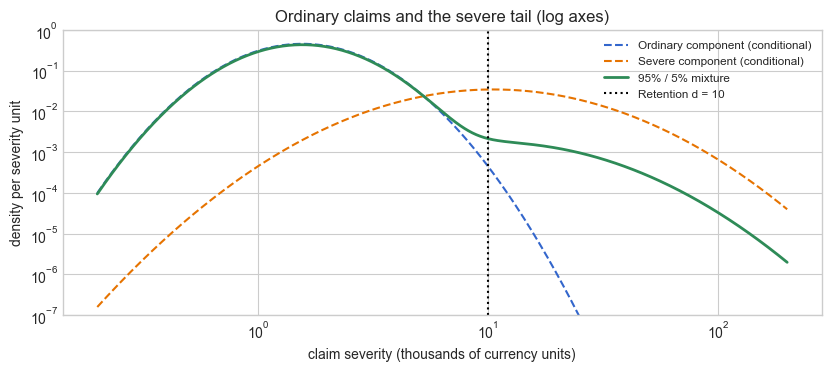

In [7]:
claim_probabilities = np.array([0.95, 0.05])
claim_distributions = [
    lognorm(s=0.5, scale=2.0),
    lognorm(s=0.8, scale=20.0),
]
retention = 10.0


def claim_mixture_pdf(x):
    return sum(
        probability * distribution.pdf(x)
        for probability, distribution in zip(
            claim_probabilities, claim_distributions
        )
    )


claim_grid = np.geomspace(0.2, 200.0, 700)
fig, ax = plt.subplots(figsize=(8.2, 3.6), layout="constrained")
ax.loglog(claim_grid, claim_distributions[0].pdf(claim_grid),
          "--", color=COLORS[0], label="Ordinary component (conditional)")
ax.loglog(claim_grid, claim_distributions[1].pdf(claim_grid),
          "--", color=COLORS[1], label="Severe component (conditional)")
ax.loglog(claim_grid, claim_mixture_pdf(claim_grid),
          color=COLORS[2], linewidth=2, label="95% / 5% mixture")
ax.axvline(retention, color="black", linestyle=":", label="Retention d = 10")
ax.set(xlabel="claim severity (thousands of currency units)",
       ylabel="density per severity unit", ylim=(1e-7, 1.0),
       title="Ordinary claims and the severe tail (log axes)")
ax.legend(loc="upper right", framealpha=1.0, fontsize=8.5)
plt.show()

The mixture follows the ordinary-claim body but retains a severe right tail beyond the retention line. Dashed curves show conditional component densities; the solid curve weights them by 0.95 and 0.05. Logarithmic axes expose both scales, while the reference calculation below integrates the complete tail to infinity.

### Expected stop-loss payment

Direct `Mixture` sampling uses 16 independently randomized digital nets with 16,384 samples per replication. Independently, quadrature computes
$$
I_{\mathrm{ref}}=\int_d^\infty(x-d)\rho_{\mathrm{mix}}(x)\,dx.
$$
The reference is also decomposed into weighted ordinary and severe contributions to show which component drives the expectation.

This example uses direct `Mixture` sampling to illustrate the severe component's effect on a tail-sensitive quantity; it does not argue that selector-based integration is preferable to the componentwise approach in Section 3. Because stop-loss is also an expectation, the componentwise identity applies here as well.

In [8]:
claim_components = [
    SciPyWrapper(DigitalNetB2(1, seed=81 + j), distribution)
    for j, distribution in enumerate(claim_distributions)
]
claim_mixture = Mixture(
    DigitalNetB2(2, seed=83, replications=16, randomize="LMS DS"),
    claim_components, claim_probabilities,
)
claim_samples = claim_mixture(2**14)[..., 0]
assert claim_samples.shape == (16, 2**14)
assert np.all(np.isfinite(claim_samples)) and np.all(claim_samples > 0)
stop_loss_by_replication = np.maximum(
    claim_samples - retention, 0.0
).mean(axis=1)
stop_loss_estimate = stop_loss_by_replication.mean()

stop_loss_reference, stop_loss_quad_error = quad(
    lambda x: (x - retention) * claim_mixture_pdf(x),
    retention, np.inf, epsabs=1e-10, epsrel=1e-10,
)
stop_loss_rmse = np.sqrt(
    np.mean((stop_loss_by_replication - stop_loss_reference) ** 2)
)
component_stop_loss = np.array([
    quad(
        lambda x: (x - retention) * distribution.pdf(x),
        retention, np.inf, epsabs=1e-10, epsrel=1e-10,
    )[0]
    for distribution in claim_distributions
])
weighted_contributions = claim_probabilities * component_stop_loss
severe_share = weighted_contributions[1] / stop_loss_reference
np.testing.assert_allclose(
    weighted_contributions.sum(), stop_loss_reference, rtol=1e-10, atol=1e-10
)
assert stop_loss_quad_error < 1e-8

# Convert from thousands to currency units only for reporting.
print(f"Direct Mixture QMC estimate: {1000 * stop_loss_estimate:.2f}")
print(f"Quadrature reference:        {1000 * stop_loss_reference:.2f}")
print(f"Absolute error:              {1000 * abs(stop_loss_estimate - stop_loss_reference):.2f}")
print(f"Replication RMSE:           {1000 * stop_loss_rmse:.2f}")
print(f"Ordinary contribution:       {1000 * weighted_contributions[0]:.2f}")
print(f"Severe contribution:         {1000 * weighted_contributions[1]:.2f}")
print(f"Severe share of reference:   {100 * severe_share:.2f}%")
print("All amounts are currency units per claim.")

Direct Mixture QMC estimate: 910.42
Quadrature reference:        908.78
Absolute error:              1.64
Replication RMSE:           9.33
Ordinary contribution:       0.94
Severe contribution:         907.85
Severe share of reference:   99.90%
All amounts are currency units per claim.


The direct estimate is **910.42** currency units per claim, compared with the independent reference **908.78**, an absolute difference of **1.64**. This is the average excess above the 10,000-unit retention across all claims, including zero payments below retention.

Only 5% of claims belong to the severe component, yet it contributes about **907.85**, or **99.90%**, of the reference stop-loss payment; the ordinary component contributes about **0.94**. The parameters are illustrative, and the observed QMC error is not a guaranteed error bound.

## 6. Implementation status

| Feature | PR #615 status |
| --- | --- |
| Multiple components | Implemented |
| Probability validation | Implemented |
| Common output dimension validation | Implemented |
| Selector boundary convention | Implemented |
| Recursive component transforms | Implemented |
| Full mixture density / `_weight` | Implemented |
| Mean | Implemented |
| Covariance | Implemented |
| Variance | Implemented |
| Standard deviation | Implemented |
| `spawn` | Implemented |
| Replicated samplers | Tested |
| $d+1 \to d$ direct `AbstractIntegrand` integration | Not implemented |
| Automatic componentwise mixture integration API | Not implemented |

## 7. Scope and limitations

- Components must share an output dimension, and probabilities must be finite, positive, and sum to one.
- A density formula requires component densities with respect to a common reference measure. Components with point masses need a measure-level interpretation rather than an ordinary smooth density.
- `Mixture` has sampler dimension $d+1$ and output dimension $d$. The current `AbstractIntegrand` pipeline assumes those dimensions align, so direct `Mixture` integration through that interface is not currently supported.
- Componentwise QMC is demonstrated mathematically and numerically here, but PR #615 does not add an automatic componentwise mixture-integration API.
- The application parameters are illustrative; numerical accuracy does not establish that a model fits real data.

## 8. Final takeaway

- Selector-coordinate `Mixture` is a valid direct mixture sampler.
- Selector boundaries introduce discontinuities.
- For the tested expectation, componentwise QMC performs much better, including under an equal component-transform budget.
- Direct mixture samples remain useful for nonlinear distribution summaries such as medians and quantiles.
- How QMCPy should expose componentwise mixture integration remains an open architectural question.